In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path
import pandas as pd

fact = pd.read_parquet("/content/drive/My Drive/NSW_Electricity_Demand/Data/Processed/fact_merged_clean.parquet")

print("Dataset loaded successfully.")

#### Weekday and Weekend  Variable creation

import pandas as pd

# Ensure DATETIME is a datetime column
fact["DATETIME"] = pd.to_datetime(
    fact["DATETIME"],
    errors="coerce"
)

# Monday=0, ..., Saturday=5, Sunday=6
fact["DayType"] = fact["DATETIME"].dt.dayofweek.apply(
    lambda day: "Weekend" if day >= 5 else "Weekday"
)

#### Month / Season

# Ensure month and season columns exist
fact["Month"] = fact["DATETIME"].dt.month
fact["MonthName"] = fact["DATETIME"].dt.month_name()

def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

fact["Season"] = fact["Month"].apply(get_season)

# Month order starting from December
month_order = [
    "December", "January", "February", "March", "April", "May",
    "June", "July", "August", "September", "October", "November"
]
fact["MonthName"] = pd.Categorical(fact["MonthName"], categories=month_order, ordered=True)

Dataset loaded successfully.


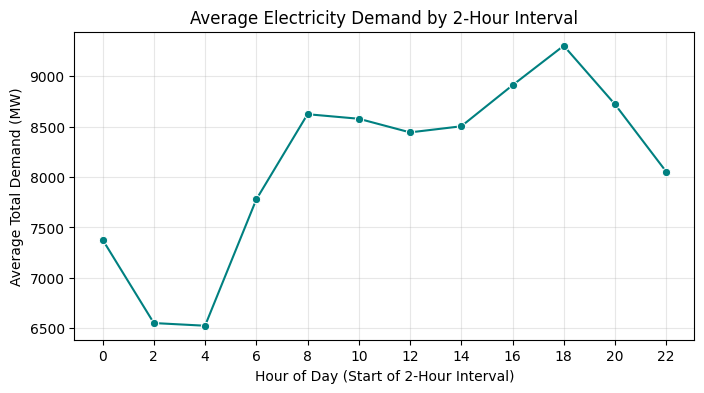

In [4]:
#### Average Electricity Demand By Two hour Window

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 2-hour bin column
fact["Hour"] = fact["DATETIME"].dt.hour
fact["HourBin"] = (fact["Hour"] // 2) * 2  # e.g., 0–1 → 0, 2–3 → 2, etc.

# Group by 2-hour bins
hourly_2h = fact.groupby("HourBin")["TOTALDEMAND"].mean().reset_index()

# Plot
plt.figure(figsize=(8,4))
sns.lineplot(data=hourly_2h, x="HourBin", y="TOTALDEMAND", marker="o", color="teal")
plt.title("Average Electricity Demand by 2-Hour Interval")
plt.xlabel("Hour of Day (Start of 2-Hour Interval)")
plt.ylabel("Average Total Demand (MW)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.show()


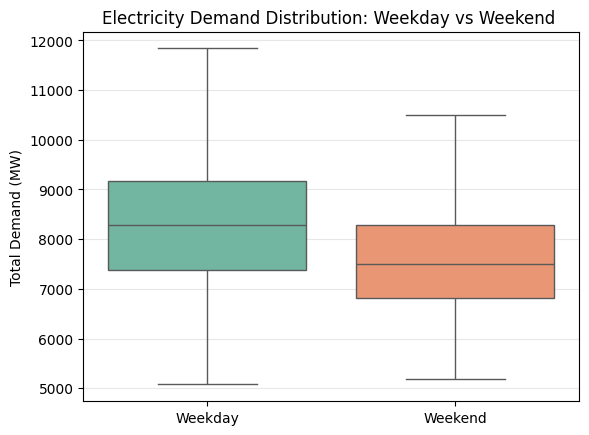

In [5]:
#### Electricity Demand distribution by Weekday or Weekend
sns.boxplot(
    data=fact,
    x="DayType",
    y="TOTALDEMAND",
    hue="DayType",
    palette="Set2",
    showfliers=False,      # hides the outlier dots
    legend=False
)
plt.title("Electricity Demand Distribution: Weekday vs Weekend ")
plt.xlabel("")
plt.ylabel("Total Demand (MW)")
plt.grid(axis="y", alpha=0.3)
plt.show()


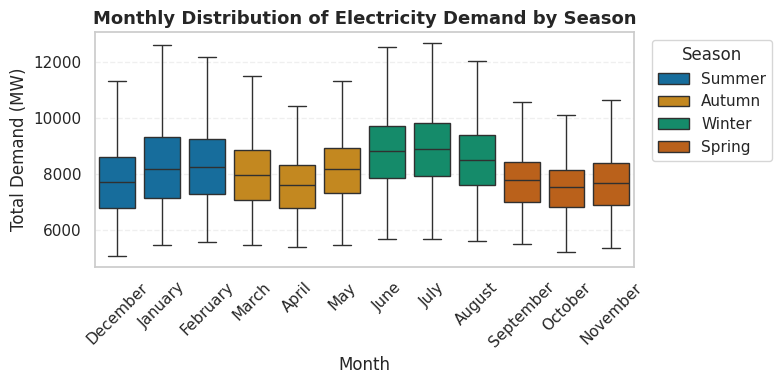

In [6]:
# Seaborn theme with natural look
sns.set_theme(style="whitegrid", palette="colorblind")

# Plot
plt.figure(figsize=(8,4))
sns.boxplot(
    data=fact,
    x="MonthName", y="TOTALDEMAND",
    hue="Season",
    showfliers=False,               # hide statistical outliers
    linewidth=1
)

plt.title("Monthly Distribution of Electricity Demand by Season", fontsize=13, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Demand (MW)")
plt.xticks(rotation=45)
plt.legend(title="Season", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.grid(axis='y', alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


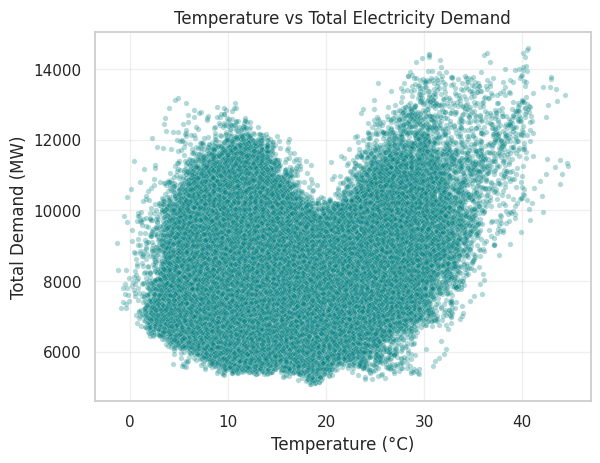

In [7]:
sns.scatterplot(
    data=fact, x="TEMPERATURE", y="TOTALDEMAND",
    alpha=0.3, s=15, color="teal"
)
plt.title("Temperature vs Total Electricity Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Demand (MW)")
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_1033/2048805054.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_demand = fact.groupby("TempBin")["TOTALDEMAND"].mean().reset_index()
/tmp/ipykernel_1033/2048805054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_demand, x="TempBin", y="TOTALDEMAND", palette="Spectral")


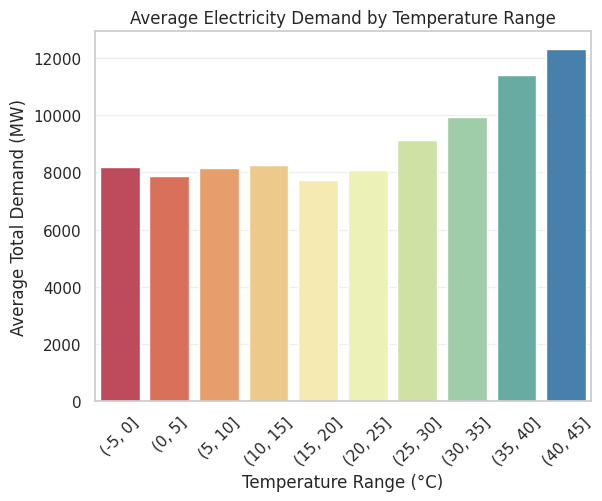

In [8]:
bins = range(-5, 50, 5)
fact["TempBin"] = pd.cut(fact["TEMPERATURE"], bins=bins)

temp_demand = fact.groupby("TempBin")["TOTALDEMAND"].mean().reset_index()

sns.barplot(data=temp_demand, x="TempBin", y="TOTALDEMAND", palette="Spectral")
plt.xticks(rotation=45)
plt.title("Average Electricity Demand by Temperature Range")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Total Demand (MW)")
plt.grid(axis='y', alpha=0.3)
plt.show()

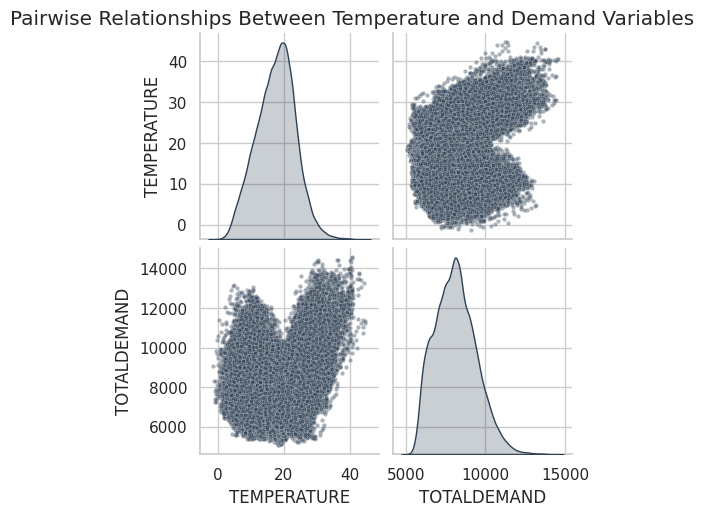

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric variables of interest
pair_vars = ["TEMPERATURE", "TOTALDEMAND"]

# Use a simple, color-blind-friendly style
sns.set(style="whitegrid")

# Create pairplot
sns.pairplot(
    data=fact[pair_vars],
    diag_kind="kde",                      # show smooth histograms on diagonal
    plot_kws={"alpha":0.4, "color":"#2E4053", "s":10},  # grey-blue dots
    diag_kws={"color":"#2E4053"},

)
plt.suptitle("Pairwise Relationships Between Temperature and Demand Variables", y=1.02)
plt.show()


Correlation Matrix:
                 TEMPERATURE  TOTALDEMAND  FORECASTDEMAND
TEMPERATURE           1.000        0.149           0.147
TOTALDEMAND           0.149        1.000           0.998
FORECASTDEMAND        0.147        0.998           1.000


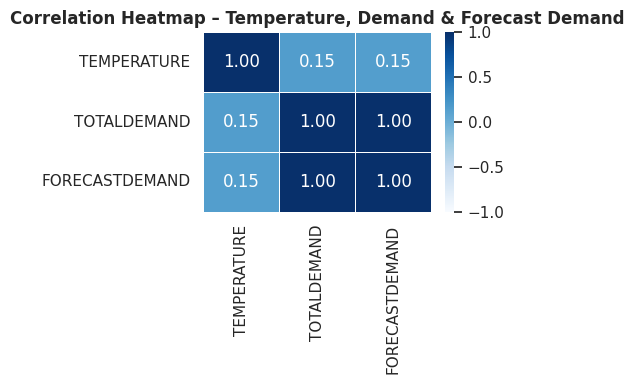

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select key numeric variables
corr_vars = ["TEMPERATURE", "TOTALDEMAND", "FORECASTDEMAND"]

# Compute the correlation matrix
corr_matrix = fact[corr_vars].corr().round(3)
print("\nCorrelation Matrix:\n", corr_matrix)

# ---- Visualize with color-blind-safe palette ----
plt.figure(figsize=(5,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",      # ✅ color-blind-friendly and perceptually uniform
    fmt=".2f",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white"
)
plt.title("Correlation Heatmap – Temperature, Demand & Forecast Demand", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

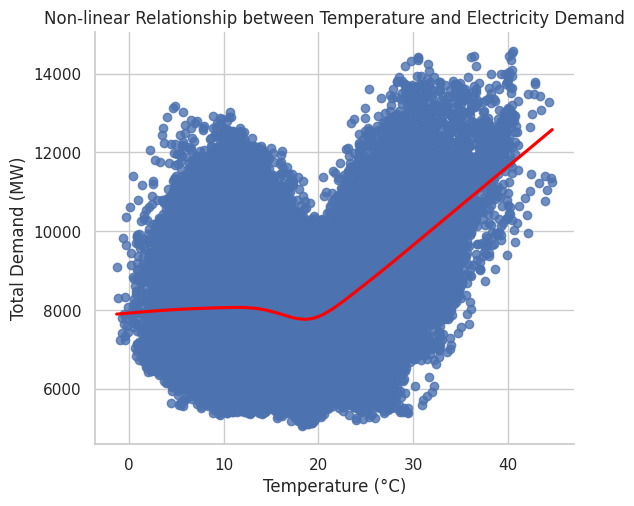

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lmplot(
    data=fact, x="TEMPERATURE", y="TOTALDEMAND",
    lowess=True, height=5, aspect=1.2, line_kws={"color":"red"}
)
plt.title("Non-linear Relationship between Temperature and Electricity Demand")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Demand (MW)")
plt.show()
